In [21]:
# %% [markdown]
# # 胸腔 X 光分類器訓練
# 
# 本 Notebook 用於訓練 ResNet18 分類器（Normal vs. Cardiomegaly）

# %%
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm  # 使用 notebook 專用的 tqdm
import warnings
import logging
import datetime
import json

warnings.filterwarnings('ignore')

# 加入專案路徑
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from data.dataset import CXRDataset, create_dataloaders
from data.preprocessing import ImagePreprocessor, DataAugmentor
from models.classifier import (
    CXRClassifier, EarlyStopping, 
    create_optimizer, create_scheduler,
    save_checkpoint, load_checkpoint
)

# --- 設定 Logger (同時輸出到螢幕與檔案) ---
RESULTS_DIR = PROJECT_ROOT / "results"
LOGS_DIR = RESULTS_DIR / "logs"
LOGS_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_filename = LOGS_DIR / f"training_log_{timestamp}.txt"

# 設定 logging
logger = logging.getLogger("CXR_Training")
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s | %(message)s', datefmt='%Y-%m-%d %H:%M:%S')

# 檔案輸出
file_handler = logging.FileHandler(log_filename, encoding='utf-8')
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

# 螢幕輸出 (StreamHandler) - 選擇性開啟，因為 print 已經會顯示
# 這裡我們定義一個 print_log 函式來同時做這兩件事
def print_log(message):
    print(message)
    logger.info(message)

print_log(f"✅ 套件載入完成，Log 將儲存於: {log_filename}")

✅ 套件載入完成，Log 將儲存於: d:\master\DGM\final_project\cxr-counterfactual-explanation\results\logs\training_log_2025-12-15_19-06-46.txt


In [22]:
# 這是我們的新武器：隨機高斯雜訊
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05): # std=0.05 代表 5% 的雜訊強度
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        # 產生與圖片大小相同的隨機雜訊
        noise = torch.randn(tensor.size()) * self.std + self.mean
        # 把雜訊加到圖片上，並確保數值不會超過範圍
        return tensor + noise
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

In [23]:
# %% [markdown]
# ## 1. 設定與路徑

# %%
# 裝置設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print_log(f"使用裝置: {device}")
if torch.cuda.is_available():
    print_log(f"GPU: {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print_log(f"VRAM: {vram:.2f} GB")

# 路徑設定 (改為讀取 processed 資料)
DATA_ROOT = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_ROOT / "processed"
IMAGES_DIR = DATA_ROOT / "raw" / "images"
MODELS_DIR = PROJECT_ROOT / "models" / "classifier"

# 建立目錄
MODELS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)

print_log(f"\n路徑設定:")
print_log(f"  處理後資料: {PROCESSED_DIR}")
print_log(f"  影像目錄: {IMAGES_DIR}")
print_log(f"  模型存檔: {MODELS_DIR}")

使用裝置: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
VRAM: 15.99 GB

路徑設定:
  處理後資料: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\processed
  影像目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\raw\images
  模型存檔: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier


In [24]:
# %% [markdown]
# ## 2. 超參數設定

# %%
CONFIG = {
    # 資料
    'image_size': (512, 512),
    'batch_size': 16,
    'num_workers': 0,  # Windows 建議設為 0
    
    # 模型
    'num_classes': 2,
    'pretrained': True,
    'dropout_rate': 0.5, # 稍微調高 dropout 避免過擬合
    
    # 訓練
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4, # 增加正則化強度
    'optimizer': 'adam',
    'scheduler': 'reduce_on_plateau',
    
    # 早停
    'early_stop_patience': 10
}

print_log("超參數設定:")
for key, value in CONFIG.items():
    print_log(f"  {key}: {value}")

超參數設定:
  image_size: (512, 512)
  batch_size: 16
  num_workers: 0
  num_classes: 2
  pretrained: True
  dropout_rate: 0.5
  num_epochs: 50
  learning_rate: 0.0001
  weight_decay: 0.0001
  optimizer: adam
  scheduler: reduce_on_plateau
  early_stop_patience: 10


In [25]:
# %% [markdown]
# ## 3. 載入資料集 (直接讀取 Processed CSV)

# %%
TRAIN_CSV = PROCESSED_DIR / "train.csv"
VAL_CSV = PROCESSED_DIR / "val.csv"
TEST_CSV = PROCESSED_DIR / "test.csv"

if not TRAIN_CSV.exists():
    raise FileNotFoundError("❌ 找不到處理後的資料集，請先執行 preprocessing.py")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print_log(f"\n資料載入完成:")
print_log(f"  Train: {len(train_df)}")
print_log(f"  Val  : {len(val_df)}")
print_log(f"  Test : {len(test_df)}")


資料載入完成:
  Train: 357
  Val  : 78
  Test : 82


正在建立 DataLoader (Albumentations 版)...
✅ 資料集初始化完成: 357 個樣本
✅ 資料集初始化完成: 78 個樣本
✅ 資料集初始化完成: 82 個樣本
視覺化訓練樣本 (請確認是否有顆粒感/雜訊):
成功讀取 Batch，影像尺寸: torch.Size([16, 3, 512, 512])


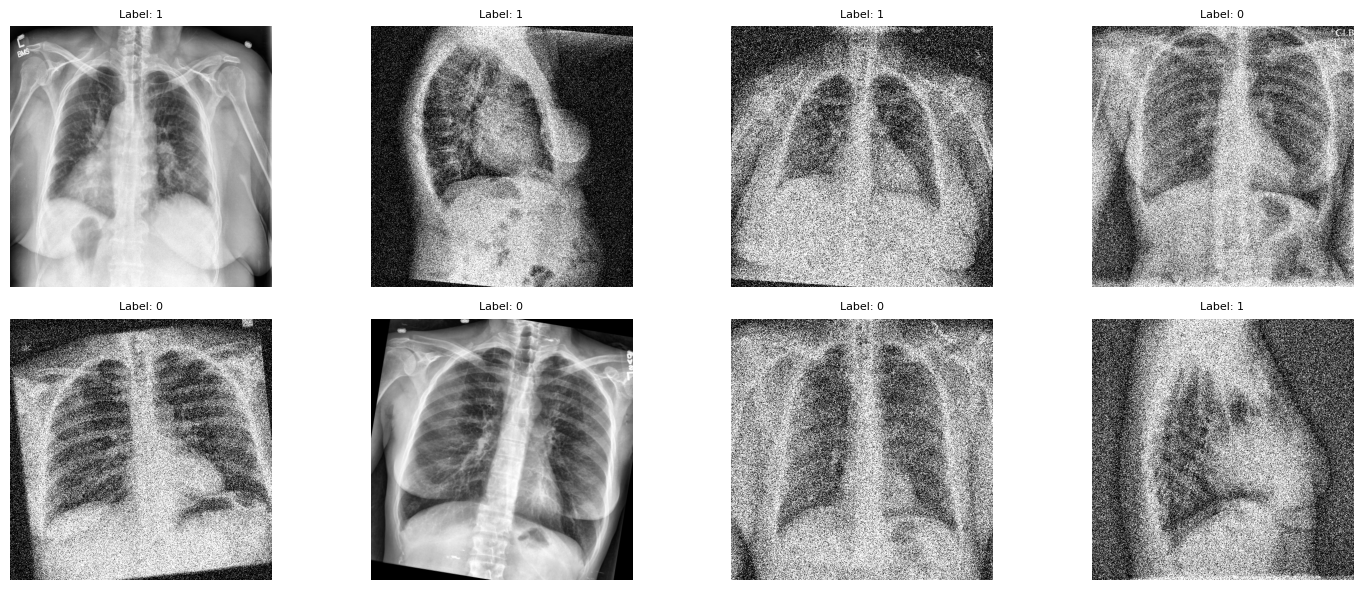

In [26]:
# %%
# ## 4. 建立 DataLoader (修正版：使用 Albumentations)

# [修正 1] 導入 albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# [修正 2] 設定前處理器
# 我們把 Resize 和 Normalize 都移到下方的 albumentations 裡做，這裡只負責讀取
preprocessor = ImagePreprocessor(
    target_size=CONFIG['image_size'],
    apply_clahe=True,
    normalize=False  # 關閉這裡的歸一化，交給下面處理
)

# [修正 3] 定義 Albumentations 訓練流程 (這是 Dataset 看得懂的格式)
train_transform_noisy = A.Compose([
    A.Resize(CONFIG['image_size'][0], CONFIG['image_size'][1]),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    
    # [關鍵武器] 高斯雜訊 (GaussNoise)
    # var_limit=(10.0, 50.0): 雜訊變異數範圍 (對應 0-255 的像素值)
    # p=1.0: 每一張圖都一定要加雜訊 (特訓！)
    A.GaussNoise(var_limit=(10.0, 30.0), mean=0, p=0.5),
    
    # 歸一化與轉 Tensor
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# 驗證集流程 (不加雜訊)
val_transform = A.Compose([
    A.Resize(CONFIG['image_size'][0], CONFIG['image_size'][1]),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# 4. 建立 DataLoader
print_log("正在建立 DataLoader (Albumentations 版)...")

train_loader, val_loader, test_loader = create_dataloaders(
    train_df, val_df, test_df,
    images_dir=IMAGES_DIR,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    
    preprocessor=preprocessor, 
    
    # 傳入修正後的 albumentations transform
    train_aug=train_transform_noisy, 
    val_aug=val_transform
)

# --- 視覺化檢查 ---
def visualize_batch(loader, n_samples=8):
    try:
        # Albumentations 處理完會直接回傳 Tensor
        batch = next(iter(loader))
        images, labels, ids = batch[0], batch[1], batch[2]
        print(f"成功讀取 Batch，影像尺寸: {images.shape}") 
    except Exception as e:
        print(f"無法讀取 batch: {e}")
        import traceback
        traceback.print_exc()
        return

    n_cols = 4
    n_rows = int(np.ceil(n_samples / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
    axes = axes.flatten()
    
    for idx in range(min(n_samples, len(images))):
        img = images[idx].cpu().numpy().transpose(1, 2, 0)
        
        # 反歸一化 (Mean=0.5, Std=0.5) -> 原圖
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)
        
        if img.shape[2] == 3:
            # 如果是 3 通道但看起來像灰階，只取一層顯示比較清楚
            pass 
        
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(f"Label: {labels[idx].item()}", fontsize=8)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("視覺化訓練樣本 (請確認是否有顆粒感/雜訊):")
visualize_batch(train_loader, n_samples=8)

In [27]:
# %% [markdown]
# ## 5-7. 模型初始化與訓練準備 (最終修正：移除權重 + 凍結 BN)

# %%
# 1. 初始化模型
model = CXRClassifier(
    num_classes=CONFIG['num_classes'],
    pretrained=True,
    dropout_rate=0.5  # 維持高 Dropout 防止過擬合
)
model = model.to(device)

# --- [技巧 1] 解凍權重，但鎖住 Batch Norm ---
# 這對於小 Batch Size (16) 的微調非常重要，可以防止模型震盪
print_log("🔓 解凍模型權重，但凍結 Batch Normalization 層...")
model.unfreeze_backbone()
'''
def freeze_bn(m):
    classname = m.__class__.__name__
    if classname.find('BatchNorm') != -1:
        m.eval() # 設定為評估模式，使用累積的統計數據
        m.weight.requires_grad = False # 不更新 gamma
        m.bias.requires_grad = False   # 不更新 beta

model.apply(freeze_bn) # 應用這個設定
'''
# 顯示真正會更新的參數
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print_log(f"實際訓練參數: {trainable_params:,}")
# ---------------------------------------------

# 2. [技巧 2] 移除 Class Weights
# 因為我們在 preprocessing 已經做過資料平衡 (Undersampling)，
# 如果再加權重，會導致模型過度偏向少數類 (全部猜有病)
print_log("⚖️ 使用標準 CrossEntropyLoss (不加權重，依賴資料平衡)")
criterion = nn.CrossEntropyLoss() 

# 3. 設定優化器
optimizer = create_optimizer(
    model, 
    optimizer_name='adam', 
    learning_rate=1e-4,  # 保持小 LR
    weight_decay=1e-3    # [加強] 增加正則化強度 (原本 1e-4 -> 1e-3) 以對抗過擬合
)

# 4. 設定調度器與早停
scheduler = create_scheduler(optimizer, scheduler_name=CONFIG['scheduler'])
early_stopping = EarlyStopping(patience=CONFIG['early_stop_patience'])

print_log("✅ 模型最終設定完成 (No Weights + Frozen BN)")

✅ 分類器初始化完成
   - 骨幹網路: ResNet18
   - 預訓練權重: IMAGENET1K_V1
   - 特徵維度: 512
   - 類別數: 2
🔓 解凍模型權重，但凍結 Batch Normalization 層...
✅ 所有層已解凍
實際訓練參數: 11,308,354
⚖️ 使用標準 CrossEntropyLoss (不加權重，依賴資料平衡)
✅ 優化器建立: ADAM, LR: 0.0001, WD: 0.001
✅ 學習率調度器: reduce_on_plateau
✅ 模型最終設定完成 (No Weights + Frozen BN)


In [28]:
# %% [markdown]
# ## 8. 開始訓練

# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 使用 tqdm 顯示進度
    pbar = tqdm(loader, desc='Training', leave=False)
    
    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return running_loss / len(loader), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            probs = F.softmax(outputs, dim=1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return running_loss / len(loader), 100 * correct / total, all_preds, all_labels, all_probs

# --- 主訓練迴圈 ---
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_loss = float('inf')
best_epoch = 0

print_log("\n🚀 開始訓練...")

for epoch in range(1, CONFIG['num_epochs'] + 1):
    # 訓練與驗證 
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    
    # 記錄數據
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)
    
    # 輸出 Log (同時顯示在螢幕與檔案)
    log_msg = (f"Epoch {epoch:02d} | "
               f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.1f}% | "
               f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.1f}% | "
               f"LR: {current_lr:.2e}")
    print_log(log_msg)
    
    # Scheduler 調整學習率
    if CONFIG['scheduler'] == 'reduce_on_plateau':
        scheduler.step(val_loss)
    else:
        scheduler.step()
        
    # 儲存最佳模型 Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        save_checkpoint(model, optimizer, epoch, val_loss, MODELS_DIR / "best_model.pth")
        
    # 早停檢查
    if early_stopping(val_loss):
        print_log(f"🛑 早停觸發於 Epoch {epoch}")
        break

print_log(f"\n🎉 訓練完成！最佳模型在 Epoch {best_epoch}, Val Loss: {best_val_loss:.4f}")

# 儲存歷史記錄 CSV
pd.DataFrame(history).to_csv(RESULTS_DIR / "metrics" / "training_history.csv", index=False)


🚀 開始訓練...


Training:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.6883, Acc: 58.3% | Val Loss: 0.6358, Acc: 71.8% | LR: 1.00e-04
💾 模型存檔: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier\best_model.pth


Training:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.6249, Acc: 64.1% | Val Loss: 0.5813, Acc: 74.4% | LR: 1.00e-04
💾 模型存檔: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier\best_model.pth


...

Epoch 21 | Train Loss: 0.2596, Acc: 89.4% | Val Loss: 0.4531, Acc: 78.2% | LR: 5.00e-05


Training:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 22 | Train Loss: 0.2660, Acc: 89.1% | Val Loss: 0.5314, Acc: 73.1% | LR: 5.00e-05


Training:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 23 | Train Loss: 0.2617, Acc: 88.0% | Val Loss: 0.4417, Acc: 75.6% | LR: 5.00e-05

⚠️ 早停觸發！已連續 10 個 epoch 無改善
🛑 早停觸發於 Epoch 23

🎉 訓練完成！最佳模型在 Epoch 13, Val Loss: 0.3742


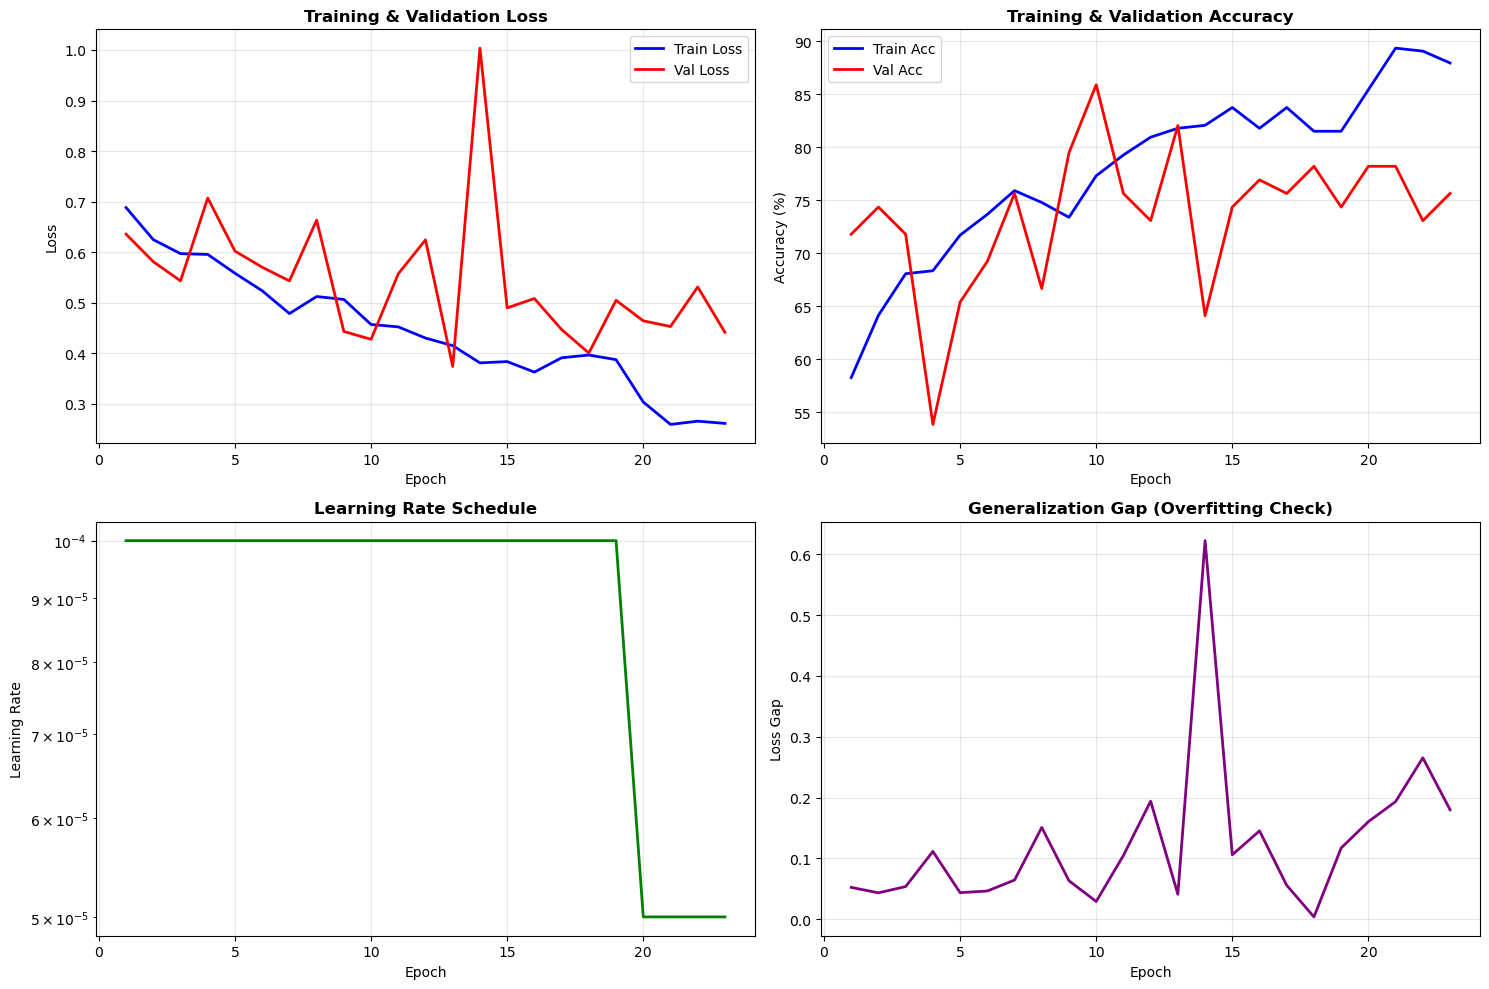

📊 訓練歷史圖表已儲存: d:\master\DGM\final_project\cxr-counterfactual-explanation\results\figures\training_history.png


In [29]:
# %% [markdown]
# ## 9. 視覺化訓練過程

# %%
def plot_training_history(history):
    """繪製訓練歷史並儲存"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 1. Loss 曲線
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Accuracy 曲線
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Learning Rate 變化
    axes[1, 0].plot(epochs, history['lr'], 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Generalization Gap (Loss 差距)
    loss_gap = [abs(t - v) for t, v in zip(history['train_loss'], history['val_loss'])]
    axes[1, 1].plot(epochs, loss_gap, 'purple', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss Gap')
    axes[1, 1].set_title('Generalization Gap (Overfitting Check)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = RESULTS_DIR / "figures" / "training_history.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print_log(f"📊 訓練歷史圖表已儲存: {save_path}")

plot_training_history(history)

In [30]:
# %% [markdown]
# ## 10. 載入最佳模型並在測試集評估 (含 TTA 增強)

# %%
print_log("\n🔍 正在載入最佳模型進行最終測試...")

# 1. 重新載入模型架構
best_model = CXRClassifier(
    num_classes=CONFIG['num_classes'],
    pretrained=False, 
    dropout_rate=CONFIG['dropout_rate']
).to(device)

# 2. 載入權重
checkpoint_path = MODELS_DIR / "best_model.pth"
load_checkpoint(best_model, None, checkpoint_path, device)
best_model.eval()

# 3. 定義 TTA 預測函數 (原圖 + 水平翻轉 取平均)
def predict_with_tta(model, loader, device):
    print_log("⚡ 啟動 TTA (Test Time Augmentation) 預測模式...")
    model.eval()
    
    all_preds, all_labels, all_probs = [], [], []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels, _ in tqdm(loader, desc="TTA Testing"):
            images, labels = images.to(device), labels.to(device)
            
            # A. 預測原圖
            out1 = model(images)
            prob1 = F.softmax(out1, dim=1)
            
            # B. 預測翻轉圖
            # dim=3 是寬度維度 [Batch, Channel, Height, Width]
            images_flipped = torch.flip(images, dims=[3]) 
            out2 = model(images_flipped)
            prob2 = F.softmax(out2, dim=1)
            
            # C. 取平均
            avg_prob = (prob1 + prob2) / 2
            
            # D. 取得最終預測
            _, predicted = torch.max(avg_prob, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(avg_prob.cpu().numpy())
            
    acc = 100 * correct / total
    return acc, all_preds, all_labels, all_probs

# 4. 執行測試
# 先算一次標準的 (為了記錄 Loss)
test_loss, std_acc, _, _, _ = validate(best_model, test_loader, criterion, device)

# 再算一次 TTA 的
tta_acc, test_preds, test_labels, test_probs = predict_with_tta(best_model, test_loader, device)

print_log(f"\n🏆 測試集最終結果:")
print_log(f"  Test Loss (Standard): {test_loss:.4f}")
print_log(f"  Test Acc  (Standard): {std_acc:.2f}%")
print_log(f"  Test Acc  (w/ TTA)  : {tta_acc:.2f}%  <-- 推薦使用此結果")


🔍 正在載入最佳模型進行最終測試...
✅ 分類器初始化完成
   - 骨幹網路: ResNet18
   - 預訓練權重: None
   - 特徵維度: 512
   - 類別數: 2
📖 載入檢查點: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier\best_model.pth
⚡ 啟動 TTA (Test Time Augmentation) 預測模式...


TTA Testing:   0%|          | 0/6 [00:00<?, ?it/s]


🏆 測試集最終結果:
  Test Loss (Standard): 0.6456
  Test Acc  (Standard): 74.39%
  Test Acc  (w/ TTA)  : 74.39%  <-- 推薦使用此結果



📄 詳細分類報告:

              precision    recall  f1-score   support

      Normal     0.6909    0.9048    0.7835        42
Cardiomegaly     0.8519    0.5750    0.6866        40

    accuracy                         0.7439        82
   macro avg     0.7714    0.7399    0.7350        82
weighted avg     0.7694    0.7439    0.7362        82

混淆矩陣:
[[38  4]
 [17 23]]


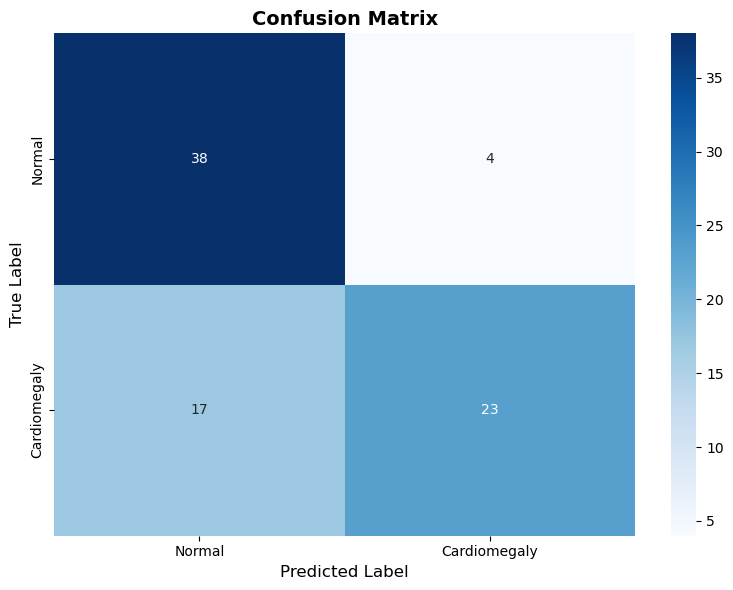

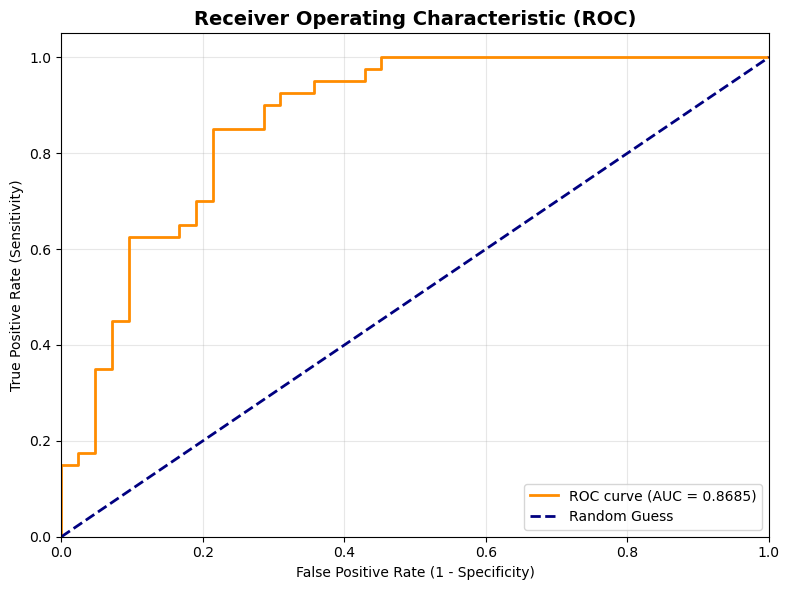

✅ AUC-ROC Score: 0.8685


In [31]:
# %% [markdown]
# ## 11. 詳細評估指標

# %%
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. 分類報告
print_log("\n📄 詳細分類報告:")
report = classification_report(
    test_labels, test_preds,
    target_names=['Normal', 'Cardiomegaly'],
    digits=4
)
print_log("\n" + report)

# 2. 混淆矩陣
cm = confusion_matrix(test_labels, test_preds)
print_log(f"混淆矩陣:\n{cm}")

# 繪製混淆矩陣
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Cardiomegaly'],
            yticklabels=['Normal', 'Cardiomegaly'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "confusion_matrix.png", dpi=150)
plt.show()

# 3. ROC 曲線
# 取出正例 (Cardiomegaly) 的機率值
test_probs_positive = [prob[1] for prob in test_probs]
fpr, tpr, thresholds = roc_curve(test_labels, test_probs_positive)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "roc_curve.png", dpi=150)
plt.show()

print_log(f"✅ AUC-ROC Score: {roc_auc:.4f}")

In [32]:
# %% [markdown]
# ## 12. 儲存實驗數據

# %%
# 1. 儲存測試指標 JSON
test_results = {
    'test_loss': test_loss,
    'test_accuracy': tta_acc,
    'auc_roc': roc_auc,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'config': CONFIG  # 把這次實驗的參數也存起來
}

json_path = RESULTS_DIR / "metrics" / "test_results.json"
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(test_results, f, indent=4, ensure_ascii=False)

# 2. 儲存逐筆預測結果 CSV (方便後續分析錯誤案例)
predictions_df = pd.DataFrame({
    'image_id': test_df['image_id'].values,
    'true_label': test_labels,
    'predicted_label': test_preds,
    'prob_normal': [prob[0] for prob in test_probs],
    'prob_cardiomegaly': [prob[1] for prob in test_probs]
})

pred_csv_path = RESULTS_DIR / "metrics" / "test_predictions.csv"
predictions_df.to_csv(pred_csv_path, index=False)

print_log("\n💾 所有實驗結果已存檔:")
print_log(f"  - 訓練歷史 (CSV): {RESULTS_DIR / 'metrics' / 'training_history.csv'}")
print_log(f"  - 測試指標 (JSON): {json_path}")
print_log(f"  - 預測詳情 (CSV): {pred_csv_path}")
print_log(f"  - 最佳模型 (PTH): {MODELS_DIR / 'best_model.pth'}")
print_log("="*60)
print_log("🎉 Notebook 執行完畢！")

# 關閉 Log handler 避免下次執行重複寫入
handlers = logger.handlers[:]
for handler in handlers:
    handler.close()
    logger.removeHandler(handler)


💾 所有實驗結果已存檔:
  - 訓練歷史 (CSV): d:\master\DGM\final_project\cxr-counterfactual-explanation\results\metrics\training_history.csv
  - 測試指標 (JSON): d:\master\DGM\final_project\cxr-counterfactual-explanation\results\metrics\test_results.json
  - 預測詳情 (CSV): d:\master\DGM\final_project\cxr-counterfactual-explanation\results\metrics\test_predictions.csv
  - 最佳模型 (PTH): d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier\best_model.pth
🎉 Notebook 執行完畢！
